# Customer Churn Analysis

## Objective
The goal of this project is to analyze customer behavior and identify key factors contributing to customer churn.

We will:
- Explore multiple data sources (demographics, transactions, service, online activity)
- Perform data cleaning and feature engineering
- Identify patterns related to churn
- Prepare a dataset suitable for predictive modeling

## Dataset Overview
The dataset consists of 5 tables:

1. Customer_Demographics → Customer personal details
2. Transaction_History → Customer financial transactions
3. Customer_Service → Complaints and service interactions
4. Online_Activity → Digital engagement data
5. Churn_Status → Target variable (whether customer churned or not)

## 1. Import Libraries & Configuration

In [2]:
# Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Configurations
sns.set_style('darkgrid')

## 2. Load Dataset

In [3]:
# Define dataset path
file_path = "../data/Customer_Churn_Data_Large.xlsx"
data = pd.ExcelFile(file_path)

# Load each dataset from Excel sheets
customer_demographics = pd.read_excel(file_path, sheet_name= "Customer_Demographics")
transaction_history = pd.read_excel(file_path, sheet_name= "Transaction_History")
customer_service = pd.read_excel(file_path, sheet_name= "Customer_Service")
online_activity = pd.read_excel(file_path, sheet_name= "Online_Activity")
churn_status = pd.read_excel(file_path, sheet_name= "Churn_Status")

# Check sheet lists
print(f"Total datasets in this file - {data.sheet_names}")

Total datasets in this file - ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Define inspect fucntion for quick data inspection
def inspect(df, name):
    print(f"\n{name}")
    print("-"*40)

    print("Sample Records:")
    print(df.head())
    
    print("\nShape:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    print("\nData Info:")
    df.info()
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print(f"\nDuplicated Rows: {df.duplicated().sum()}")
    
    print("\nStatistical Summary:")
    print(df.describe())
    print("\n")



#### Dataset 1 - Customer Demographics :

In [5]:
inspect(customer_demographics, "Customer Demographics")


Customer Demographics
----------------------------------------
Sample Records:
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium

Shape:
Rows: 1000, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB

Missing Values:
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

Dupl

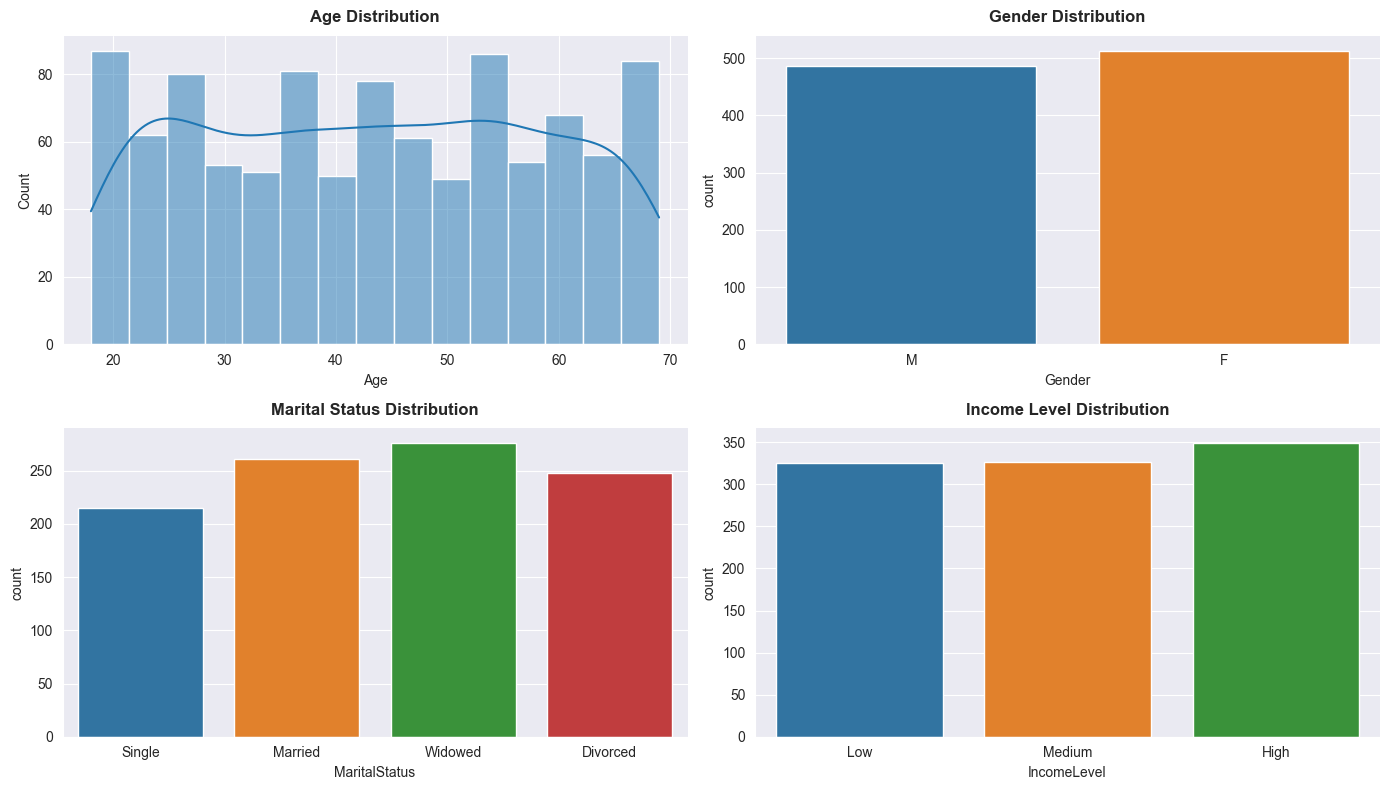

In [6]:
# Define figure size
plt.figure(figsize=(14,8))

# Age Distribution
plt.subplot(2,2,1)
sns.histplot(data=customer_demographics, x='Age',bins=15, kde=True)
plt.title('Age Distribution', fontweight='bold',pad=10)
sns.despine()

# Gender Distribution
plt.subplot(2,2,2)
sns.countplot(data=customer_demographics, x='Gender',palette='tab10')
plt.title('Gender Distribution', fontweight='bold',pad=10)
sns.despine()

# Marital Status Distribution
plt.subplot(2,2,3)
sns.countplot(data=customer_demographics, x='MaritalStatus',palette='tab10')
plt.title('Marital Status Distribution', fontweight='bold',pad=10)
sns.despine()

# Income Level Distribution
plt.subplot(2,2,4)
sns.countplot(data=customer_demographics, x='IncomeLevel',palette='tab10')
plt.title('Income Level Distribution', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Customer_Demographics_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations :
- There are 1000 rows and 5 columns in this dataset.
- The dataset contains no missing or duplicate values.
- Customer ages are distributed fairly evenly between 18 and 69 years, with an average age of approximately 43 years.
- In Gender, number of female customers are slightly higher compared to male customers.
- Widowed customers are slightly higher in number compared to other marital status categories.
- Income levels are also fairly balanced among Low, Medium, and High categories, with High income customers slightly dominating the dataset.
- No major skewness or abnormal patterns are visible in demographic features at the initial exploration stage.

#### Dataset 2 - Transaction History :

In [7]:
inspect(transaction_history, "Transaction History")


Transaction History
----------------------------------------
Sample Records:
   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing

Shape:
Rows: 5054, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[us]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  

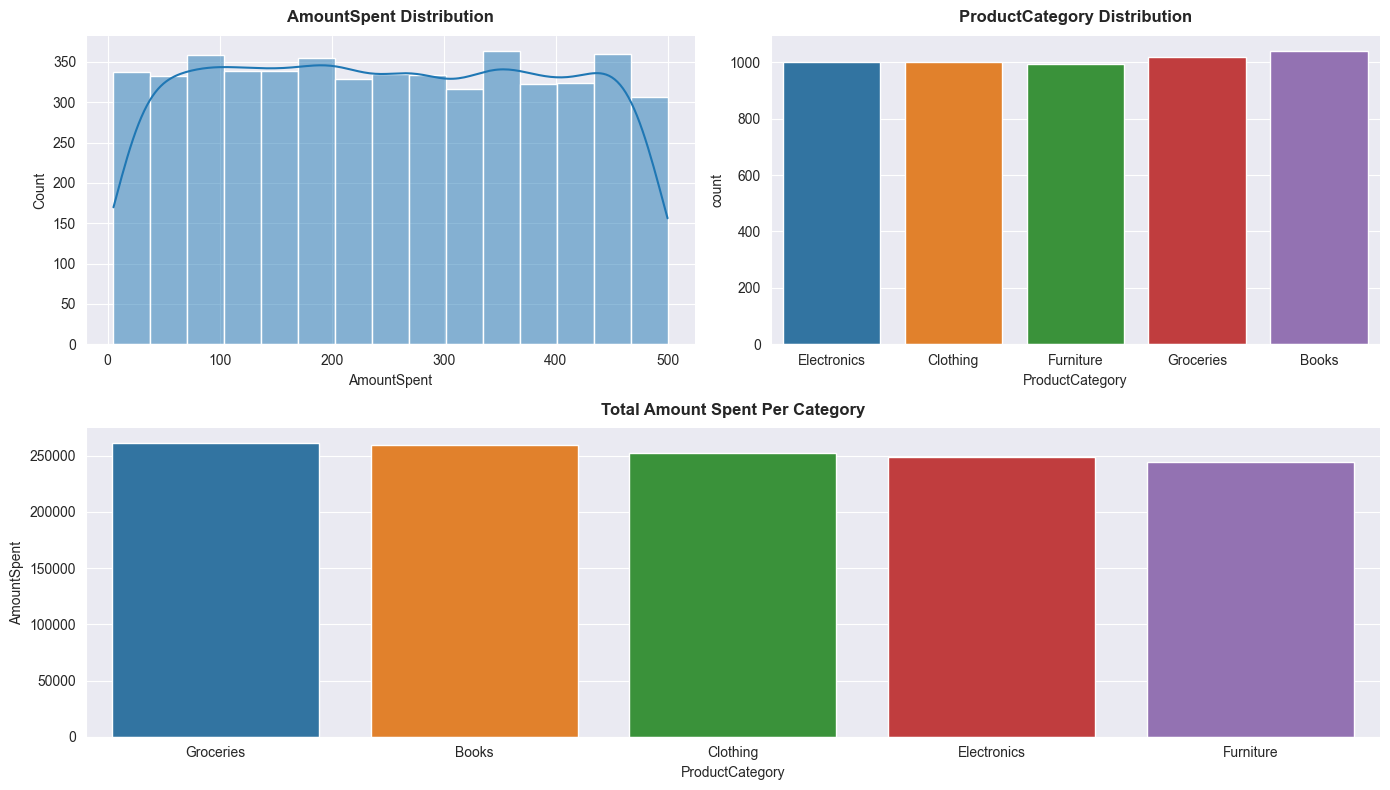

  ProductCategory  AmountSpent
0       Groceries    261133.65
1           Books    259564.99
2        Clothing    252450.70
3     Electronics    249139.79
4       Furniture    244785.82


In [8]:
plt.figure(figsize=(14,8))

# Amount Spent Distribution
plt.subplot(2,2,1)
sns.histplot(data=transaction_history,x='AmountSpent',bins=15,kde=True,palette='tab10')
plt.title('AmountSpent Distribution', fontweight='bold',pad=10)
sns.despine()

# Product Category Distribution
plt.subplot(2,2,2)
sns.countplot(data=transaction_history, x='ProductCategory',palette='tab10')
plt.title('ProductCategory Distribution', fontweight='bold',pad=10)
sns.despine()

# Aggregation
amount_per_category = (
    transaction_history.groupby('ProductCategory')['AmountSpent'].sum().sort_values(ascending=False).reset_index()
)

#  Amount Spent Per Category
plt.subplot(2,1,2)
sns.barplot(data=amount_per_category, x='ProductCategory', y='AmountSpent',palette='tab10')
plt.title('Total Amount Spent Per Category', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Transaction_History_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(amount_per_category)

#### Observations :
- Total customers are 1000 and this dataset contains 5054 records, indicating multiple transactions per customer.
- No missing or duplicate values are present in the dataset.
- Transaction amounts range from approximately 5 to 500, with an average transaction value around 251.
- Mean and median transaction amounts are nearly identical, suggesting a balanced distribution with no major skewness or extreme outliers.
- Product categories are fairly evenly distributed in terms of transaction frequency.
- Total spending across product categories is also relatively balanced, with Groceries and Books contributing slightly higher overall spending compared to other categories.
- Transaction records span the complete year of 2022, enabling future time-based transaction analysis.

#### Dataset 3 - Customer Service :

In [9]:
inspect(customer_service, "Customer Service")


Customer Service
----------------------------------------
Sample Records:
   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2           3           9976      2022-08-24         Inquiry         Resolved
3           4           7354      2022-11-18         Inquiry         Resolved
4           4           5393      2022-07-03         Inquiry       Unresolved

Shape:
Rows: 1002, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[us]
 3   InteractionType   1002 non-null   str       

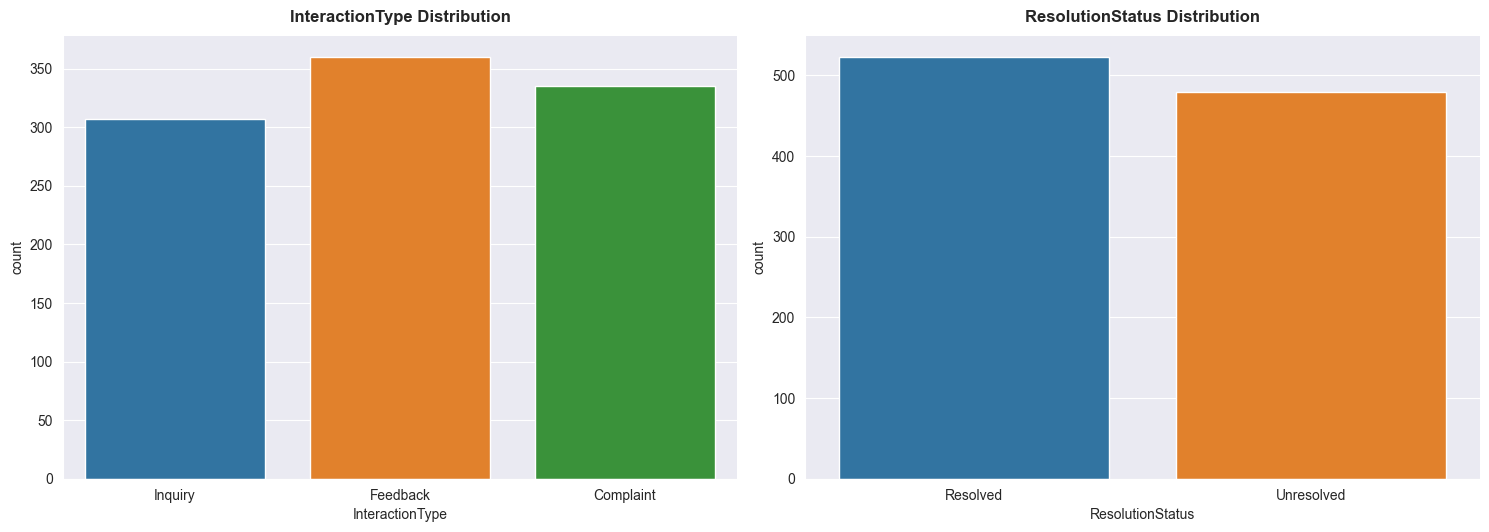

In [10]:
plt.figure(figsize=(15,10))

# Interaction Type Distribution
plt.subplot(2,2,1)
sns.countplot(data=customer_service,x='InteractionType',palette='tab10')
plt.title('InteractionType Distribution', fontweight='bold',pad=10)
sns.despine()

# Resolution Status Distribution
plt.subplot(2,2,2)
sns.countplot(data=customer_service, x='ResolutionStatus',palette='tab10')
plt.title('ResolutionStatus Distribution', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Customer_Service_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations:
- The dataset contains 1002 customer service interaction records across 1000 customers, indicating some customers had multiple service interactions.
- No missing or duplicate values are present in the dataset.
- Interaction records are fairly distributed across Inquiry, Feedback, and Complaint categories, with Feedback interactions appearing slightly more frequent.
- Resolved interactions are slightly higher than unresolved interactions, suggesting that most customer service requests are successfully handled.

#### Dataset 4 - Online Activity :

In [11]:
inspect(online_activity, "Online Activity")


Online Activity
----------------------------------------
Sample Records:
   CustomerID LastLoginDate  LoginFrequency ServiceUsage
0           1    2023-10-21              34   Mobile App
1           2    2023-12-05               5      Website
2           3    2023-11-15               3      Website
3           4    2023-08-25               2      Website
4           5    2023-10-27              41      Website

Shape:
Rows: 1000, Columns: 4

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   LastLoginDate   1000 non-null   datetime64[us]
 2   LoginFrequency  1000 non-null   int64         
 3   ServiceUsage    1000 non-null   str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 31.4 KB

Missing Values:
CustomerID        0
LastLoginDate     0
LoginFrequen

In [12]:
# Check total ServiceUsage categories
service_category = online_activity['ServiceUsage'].value_counts()
service_category


ServiceUsage
Online Banking    349
Mobile App        342
Website           309
Name: count, dtype: int64

In [13]:
# Check total LoginFrequency per ServiceUsage category
total_login_frequency = online_activity.groupby('ServiceUsage')['LoginFrequency'].sum().sort_values(ascending=False).reset_index()
total_login_frequency

,ServiceUsage,LoginFrequency
0,Online Banking,9375
1,Mobile App,8565
2,Website,7972
